In [15]:
%matplotlib inline

In [16]:
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')

import pandas as pd
import backtrader as bt
import matplotlib.pyplot as plt

In [17]:
class MyBuySell(bt.observers.BuySell):
    plotlines = dict(
        buy=dict(marker='^', markersize=8.0, color='blue', fillstyle='full'),
        sell=dict(marker='v', markersize=8.0, color='red', fillstyle='full')
    )

In [18]:
class SmaSignal(bt.Indicator):
    lines = ('signal',)
    params = (('period', 20),)

    def __init__(self):
        self.lines.signal = self.data - bt.ind.SMA(period=self.p.period)

### 백테스트용 데이터 불러오기(애플 2018년도)

In [19]:
dir_nm = "dailyStock"
target = "AAPL"
file_path = f"{dir_nm}/{target}.csv"

aapl_df = pd.read_csv(file_path, encoding="utf-8")
aapl_df['Date'] = pd.to_datetime(aapl_df['Date'])
aapl_df = aapl_df.set_index("Date")

aapl_df = aapl_df.loc["2018-01-01":"2018-12-31"]

data = bt.feeds.PandasData(dataname=aapl_df)

### 백테스트 설정

In [30]:
cerebro = bt.Cerebro(stdstats = False)

cerebro.adddata(data)
cerebro.broker.setcash(1000.0)
cerebro.add_signal(bt.SIGNAL_LONG, SmaSignal)
cerebro.addobserver(MyBuySell)
cerebro.addobserver(bt.observers.Value)

### 백테스트 실행

In [31]:
print(f'포트폴리오 시작가: {cerebro.broker.getvalue():.2f}')
cerebro.run()
print(f'포트폴리오 종료가: {cerebro.broker.getvalue():.2f}')

포트폴리오 시작가: 1000.00
포트폴리오 종료가: 1002.61


### 백테스트 결과 도식화

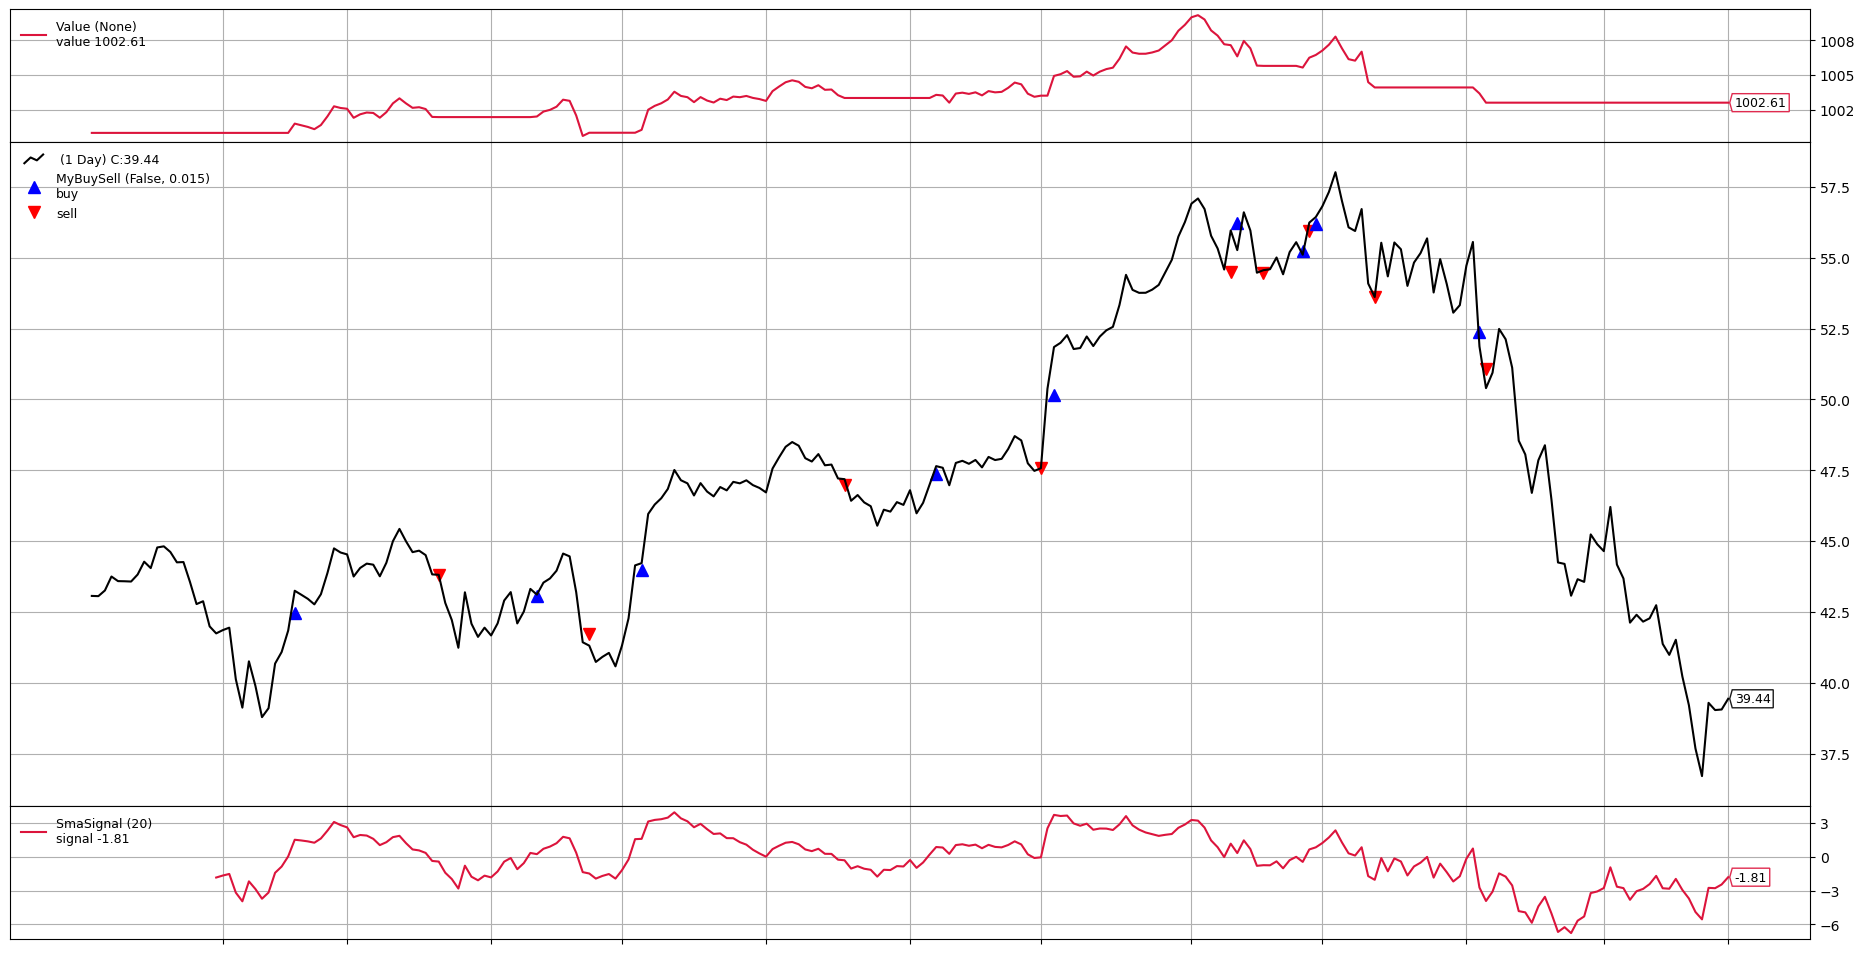

[[<Figure size 2000x1000 with 3 Axes>]]

In [32]:
plt.rcParams['figure.figsize'] = (20, 10)

cerebro.plot(iplot=False, 
             volume=False, 
             use='module://matplotlib_inline.backend_inline')